# Week 12 Supervised Learning - Classification

Earlier this week we learned the basics of a simple classifier, K-NN. We learned about train-test splits and how to evaluate models. Today we will extend this to more robust evaluation techniques, and how to "tune" hyperparameters. We will briefly cover other potential classifiers that could replace the K-NN algorithm. 

First, let's load in and prepare our data. We are again using the `ny_census` data.

In [12]:
import pandas as pd
import geopandas as gpd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler 
from sklearn.compose import make_column_transformer # This is a function for transforming all columns
from sklearn.compose import make_column_selector # This allows us to specify what types of columns to scale
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
# Let's load in our new york census data
df = pd.read_csv('ny_census.csv')
df['GEOID'] = df['GEOID'].astype(str) # We already have the GEOID but it's saved as a float

In [3]:
df.iloc[0] # We have a lot of information about each census tract

GEOID                                        36011040600
NAME           Census Tract 406, Cayuga County, New York
County                                     Cayuga County
FemaleE                                             1715
FemaleM                                              130
WhiteE                                              3208
WhiteM                                                93
BlackE                                               127
BlackM                                                56
HispanicE                                             56
HispanicM                                             59
MedIncomeE                                       84330.0
MedIncomeM                                       24381.0
TotalPopE                                           3400
TotalPopM                                             19
PovertyE                                               0
PovertyM                                              12
BachE                          

In [4]:
# Let's grab our outlines for plotting

year = 2020
state_fips = "36" #NY

url = f"https://www2.census.gov/geo/tiger/TIGER{year}/TRACT/tl_{year}_{state_fips}_tract.zip"
tracts = gpd.read_file(url)
tracts = tracts.to_crs(epsg=4326)
tracts.head()

# Merge with our census data
ny_df_tracts = pd.merge(left=df, right=tracts, on='GEOID', how='left')
ny_df_tracts.head()

,GEOID,NAME_x,County,FemaleE,FemaleM,WhiteE,WhiteM,BlackE,BlackM,HispanicE,...,TRACTCE,NAME_y,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,36011040600,"Census Tract 406, Cayuga County, New York",Cayuga County,1715,130,3208,93,127,56,56,...,040600,406,Census Tract 406,G5020,S,74642568,61548,+42.9775784,-076.5183651,"POLYGON ((-76.57121 42.99702, -76.56942 42.997..."
1,36011040700,"Census Tract 407, Cayuga County, New York",Cayuga County,1883,123,3545,72,0,12,29,...,040700,407,Census Tract 407,G5020,S,54082299,6719485,+42.8937652,-076.4932834,"POLYGON ((-76.55245 42.9264, -76.55028 42.9264..."
2,36011040800,"Census Tract 408, Cayuga County, New York",Cayuga County,1956,147,3871,229,518,156,120,...,040800,408,Census Tract 408,G5020,S,175752178,13284270,+42.7812489,-076.4204198,"POLYGON ((-76.51535 42.84096, -76.5141 42.8409..."
3,36011040900,"Census Tract 409, Cayuga County, New York",Cayuga County,1753,160,3548,295,1,3,96,...,040900,409,Census Tract 409,G5020,S,205918404,1572804,+42.6891179,-076.3568342,"POLYGON ((-76.4626 42.69178, -76.45628 42.6920..."
4,36011041001,"Census Tract 410.01, Cayuga County, New York",Cayuga County,1409,140,2807,279,0,12,153,...,041001,410.01,Census Tract 410.01,G5020,S,208974937,9752821,+42.6849182,-076.5549870,"POLYGON ((-76.68983 42.67732, -76.68666 42.677..."


In [5]:
# Let's calculate density per square mile
## ALAND is in square meters right not so we need to convert it
ny_df_tracts['ALAND_sqmi'] = ny_df_tracts['ALAND']/2.59e+6
ny_df_tracts['density_sqmi'] = ny_df_tracts['TotalPopE']/ny_df_tracts['ALAND_sqmi']

In [6]:
ny_df_tracts.density_sqmi.describe()

count      5393.000000
mean      23896.583550
std       33983.790202
min           0.000000
25%        1242.397289
50%        7217.728499
75%       36313.308499
max      311148.883375
Name: density_sqmi, dtype: float64

In [10]:
# Let's calculate a few columns of interest

def urb_rur_midsize(x):
    if x > 25000:
        return "urban"
    elif x <= 25000 and x > 7000:
        return "midsize"
    else:
        return "rural"
# urban/rural designation
ny_df_tracts['urban_rural'] = ny_df_tracts['density_sqmi'].apply(lambda x: urb_rur_midsize(x))
# percent white in each tract
ny_df_tracts['perc_white'] = ny_df_tracts['WhiteE']/ny_df_tracts['TotalPopE']
# percent below the poverty line in each tract
ny_df_tracts['perc_poverty'] =  ny_df_tracts['PovertyE']/ny_df_tracts['TotalPopE']

<Axes: >

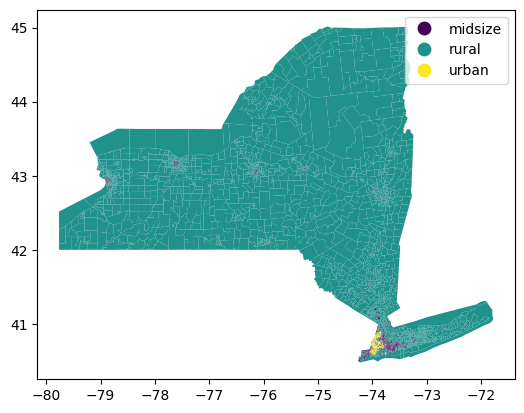

In [11]:
# convert to geodataframe and plot
ny_df_tracts = gpd.GeoDataFrame(ny_df_tracts, 
                                geometry='geometry',
                                crs='EPSG:4326')
ny_df_tracts.plot(column='urban_rural', categorical=True, legend=True, cmap='viridis')

### Recall our KNN code

In [20]:
# Keep non NA rows, and separate into training/testing sets
df_tmp = ny_df_tracts[['urban_rural', 'perc_white', 'MedIncomeE']].dropna()
df_train, df_test = train_test_split(df_tmp, train_size=0.75)

# Recall our preprocessor
preprocessor = make_column_transformer((RobustScaler(), #run the robust scaler
                                        make_column_selector(dtype_include="number")), # only on columns that are numbers
                                       remainder="passthrough", # pass through every other column
                                       verbose_feature_names_out=False) # stops long names

In [21]:
# And recall our KNN model
knn = KNeighborsClassifier(n_neighbors=5)

In [22]:
# Now we can build them into one pipeline so data always gets preprocessed the same way 
knn_pipeline = make_pipeline(preprocessor, knn)


In [23]:
# Let's fit our model
knn_pipeline.fit(X=df_train[["perc_white", "MedIncomeE"]], y=df_train["urban_rural"])


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('kneighborsclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('robustscaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

In [24]:
# Now we can predict on our test data using the same pipeline
predicted = knn_pipeline.predict(df_test[["perc_white", "MedIncomeE"]])
df_test['predicted'] = predicted # Add new column
df_test[["urban_rural", "predicted"]].head(10) # Show side by side

,urban_rural,predicted
1775,midsize,midsize
3231,rural,rural
3277,midsize,urban
2791,rural,rural
3849,rural,rural
5350,rural,urban
1848,rural,rural
1150,urban,urban
2008,urban,rural
5347,midsize,midsize


In [25]:
# How well do we do? This returns "accuracy"
knn_pipeline.score(df_test[['perc_white', 'MedIncomeE']], df_test['urban_rural'])

0.6554105909439755

## 1. Cross Validation

Every time we split our data into a training and a testing set, we make a decision about which data should be considered to build our model (training). As we saw before, each time we run this process, we can end up with a slightly different training set and this can impact our results. To combat this, we could run the train-test split process multiple times, look at the accuracy results, and take the average to get a sense of how our model performs regardless of the noise in the training set. 

In practice, we don’t have to rely on random splits, but rather we can use a more structured splitting procedure so that each observation in the data set is used in a validation set only a single time. The name for this strategy is **cross-validation**. In cross-validation, we split our overall training data into evenly sized chunks. Then, iteratively use chunk as the validation set and combine the remaining chunks as the training set. In the figure below, different chunks of the data set are used, resulting in 5 different choices for the validation set; we call this 5-fold cross-validation.
</figure>
<img src="https://python.datasciencebook.ca/_images/cv.png" alt="drawing" width="500" style="display: block; margin: 0 auto"/>
</figure>


In [63]:
from sklearn.model_selection import cross_validate

# Let's define our pipeline from scratch
knn_pipeline = make_pipeline(preprocessor, knn)

# We define the model AND fit it with data at the same time
cv_results = cross_validate(estimator=knn_pipeline,  # We pass the pipeline in 
                            cv=5, # We choose how many splits we want
                            X=df_tmp[["perc_white", "MedIncomeE"]], # X data for fitting
                            y=df_tmp["urban_rural"]) # y data for fitting
cv_results

{'fit_time': array([0.01916289, 0.01398301, 0.01184988, 0.00956011, 0.00991607]),
 'score_time': array([0.00805187, 0.00663614, 0.0052743 , 0.0046761 , 0.00472689]),
 'test_score': array([0.63147793, 0.63339731, 0.71785029, 0.62380038, 0.56388088])}

In [30]:
cv_results = pd.DataFrame(cv_results)['test_score']

# We can compute two main statistics: mean and standard error of the mean (sem)
cv_5_metrics = cv_results.agg(["mean", "sem"])
cv_5_metrics

mean    0.634081
sem     0.024554
Name: test_score, dtype: float64

`sem` is the standard error of the mean. This quantifies how precisely the sample mean estimates the true population mean, which gives more of an understanding of uncertainty. The `sem` is calculated as $\frac{\sigma}{\sqrt{n}}$ (the standard deviation over the square root of the number of folds)

In [ ]:
## YOUR TURN
## Run cross validation with 10 folds. Compute the mean and standard error. What is different from the 5-fold CV?



## 2. Choosing K

How do you choose the best number of neighbors?

Since cross-validation helps us evaluate the accuracy of our classifier, we can use cross-validation to calculate an accuracy for each value of in a reasonable range, and then pick the value of that gives us the best accuracy. The `scikit-learn` package collection provides built-in functionality, named `GridSearchCV`, to automatically handle the details for us. Before we use `GridSearchCV`, we need to create a new pipeline with a `KNeighborsClassifier` that has the number of neighbors left unspecified.

In [60]:
knn = KNeighborsClassifier()
knn_tune_pipeline = make_pipeline(preprocessor, knn)

# We can see all of the hyperparameters we can tune
knn_tune_pipeline.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('robustscaler', RobustScaler(),
                                    <sklearn.compose._column_transformer.make_column_selector object at 0x122517ad0>)],
                     verbose_feature_names_out=False)),
  ('kneighborsclassifier', KNeighborsClassifier())],
 'transform_input': None,
 'verbose': False,
 'columntransformer': ColumnTransformer(remainder='passthrough',
                   transformers=[('robustscaler', RobustScaler(),
                                  <sklearn.compose._column_transformer.make_column_selector object at 0x122517ad0>)],
                   verbose_feature_names_out=False),
 'kneighborsclassifier': KNeighborsClassifier(),
 'columntransformer__force_int_remainder_cols': 'deprecated',
 'columntransformer__n_jobs': None,
 'columntransformer__remainder': 'passthrough',
 'columntransformer__sparse_threshold': 0.3,
 'columntransformer_

In [ ]:
# We specificy the values we want to search through in a dictionary
parameter_grid = {"kneighborsclassifier__n_neighbors": range(1, 200, 5)}


In [56]:
from sklearn.model_selection import GridSearchCV

# Now we define the model so we can run through all of K
knn_tune_grid = GridSearchCV(estimator=knn_tune_pipeline, # this is our pipeline where K is not specified
                             param_grid=parameter_grid, # these are the values of K we want to try
                             cv=10) # With 10 folds in cross validation

In [57]:
# Now we pass it the data
knn_tune_grid.fit(df_tmp[["perc_white", "MedIncomeE"]],df_tmp["urban_rural"])

# We need to get the results through .cv_results_
accuracies_grid = pd.DataFrame(knn_tune_grid.cv_results_)
accuracies_grid.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_kneighborsclassifier__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.012179,0.003579,0.003673,0.000978,1,{'kneighborsclassifier__n_neighbors': 1},0.604607,0.573896,0.644914,0.545106,0.708253,0.600768,0.575816,0.552783,0.556622,0.509615,0.587238,0.053562,40
1,0.010092,0.000076,0.003414,0.000024,6,{'kneighborsclassifier__n_neighbors': 6},0.618042,0.654511,0.681382,0.610365,0.785029,0.656430,0.683301,0.585413,0.602687,0.563462,0.644062,0.060437,39
2,0.010087,0.000079,0.003674,0.000043,11,{'kneighborsclassifier__n_neighbors': 11},0.652591,0.677543,0.687140,0.618042,0.790787,0.669866,0.714012,0.612284,0.637236,0.580769,0.664027,0.056471,38
3,0.010080,0.000061,0.003908,0.000043,16,{'kneighborsclassifier__n_neighbors': 16},0.660269,0.700576,0.698656,0.621881,0.790787,0.679463,0.733205,0.625720,0.644914,0.571154,0.672662,0.059270,36
4,0.010092,0.000059,0.004136,0.000044,21,{'kneighborsclassifier__n_neighbors': 21},0.662188,0.690979,0.698656,0.627639,0.796545,0.677543,0.752399,0.635317,0.627639,0.573077,0.674198,0.061800,34


In [62]:
# We can look at the uncertainty again
accuracies_grid["sem_test_score"] = accuracies_grid["std_test_score"] / 10**(1/2)

accuracies_grid[["param_kneighborsclassifier__n_neighbors", "mean_test_score", "sem_test_score"]]

,param_kneighborsclassifier__n_neighbors,mean_test_score,sem_test_score
0,1,0.587238,0.016938
1,6,0.644062,0.019112
2,11,0.664027,0.017858
3,16,0.672662,0.018743
4,21,0.674198,0.019543
5,26,0.675543,0.019321
6,31,0.674200,0.019566
7,36,0.673818,0.018802
8,41,0.670746,0.018907
9,46,0.677465,0.018289


Text(0.5, 0, 'Number of Neighbors (k)')

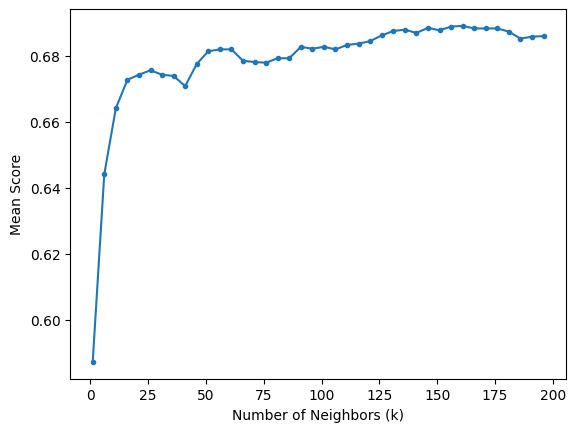

In [58]:
# Plot the K values against the mean test scores
plt.plot(accuracies_grid['param_kneighborsclassifier__n_neighbors'], accuracies_grid['mean_test_score'], '.-')
plt.ylabel('Mean Score')
plt.xlabel('Number of Neighbors (k)')


Generally, when selecting (and other parameters for other predictive models), we are looking for a value where:
* we get roughly optimal accuracy, so that our model will likely be accurate
* changing the value to a nearby one (e.g., adding or subtracting a small number) doesn’t decrease accuracy too much, so that our choice is reliable in the presence of uncertainty
* the cost of training the model is not prohibitive (e.g., in our situation, if is too large, predicting becomes expensive!)

## 3. Over- and underfitting

When we are training a classifier, we have to be careful about over- or under-fitting the training data. 

**Underfitting** is when our classifer under preforms and does not model the data well. Usually this is the case if you don't have enough training data or your model is too loose. In KNN, this might happen if you have too many neighbors who "get a say" in the value of your unknown data point. Too many neighbors can create an averaging effect where you lose the intricacies of your input data's relationship to the target values. 

**Overfitting** is when our classifier performs very well on our training set, but performs poorly on our test set because the model is too finetuned to the exact training data. In KNN, this happens when you have too few neighbors, such that each new point is only considering a few of its closest other points. The boundary between the classes becomes jagged and cannot account for what might come in the testing set or in the real world. 

</figure>
<img src="https://miro.medium.com/v2/resize:fit:1400/0*jB3VzCwWSwGXUX82.png" alt="drawing" width="700" style="display: block; margin: 0 auto"/>
</figure>


In [50]:
# Let's look at our grid search if we bump the max neighbors up to 1000

large_param_grid = {"kneighborsclassifier__n_neighbors": range(1, 1000, 10),}

# 10-fold cross validation for each value of K
large_knn_tune_grid = GridSearchCV(estimator=knn_tune_pipeline,
                                   param_grid=large_param_grid,
                                   cv=10)

#Fit our data
large_knn_tune_grid.fit(df_tmp[["perc_white", "MedIncomeE"]],df_tmp["urban_rural"])

# Save the results in a dataframe
large_accuracies_grid = pd.DataFrame(large_knn_tune_grid.cv_results_)


Text(0.5, 0, 'Number of Neighbors (k)')

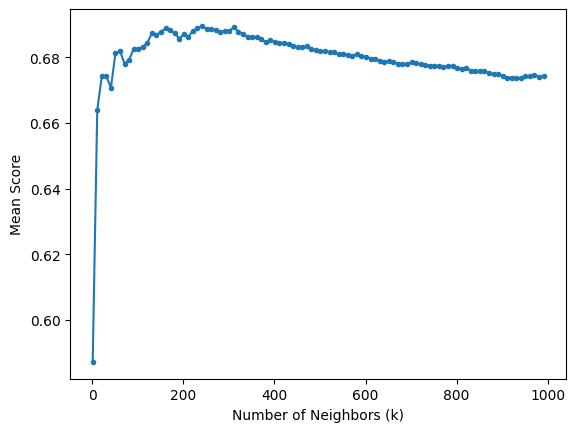

In [51]:
# Plot the K values against the mean test scores
plt.plot(large_accuracies_grid['param_kneighborsclassifier__n_neighbors'], large_accuracies_grid['mean_test_score'], '.-')
plt.ylabel('Mean Score')
plt.xlabel('Number of Neighbors (k)')

## 4. Briefly: Other Classifiers

Other classifiers: https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html


</figure>
<img src="https://scikit-learn.org/stable/_images/sphx_glr_plot_classifier_comparison_001.png" alt="drawing" width="900" style="display: block; margin: 0 auto"/>
</figure>



In [73]:
from sklearn.tree import DecisionTreeClassifier

# Create train-test
df_tmp = ny_df_tracts[['urban_rural', 'perc_white', 'MedIncomeE']].dropna()
df_train, df_test = train_test_split(df_tmp, train_size=0.75)

# Define the model and pipeline
dt = DecisionTreeClassifier()
dt_pipeline = make_pipeline(preprocessor, dt)

# Fit the data
dt_pipeline.fit(df_train[['perc_white', 'MedIncomeE']], df_train['urban_rural'])

# Predict on the test
df_test['predictions'] = dt_pipeline.predict(df_test[['perc_white', 'MedIncomeE']])

# Get accuracy results
print(classification_report(df_test["urban_rural"], df_test["predictions"]))
pd.crosstab(df_test["urban_rural"], df_test["predictions"])


              precision    recall  f1-score   support

     midsize       0.25      0.28      0.27       231
       rural       0.75      0.71      0.73       629
       urban       0.56      0.58      0.57       443

    accuracy                           0.59      1303
   macro avg       0.52      0.52      0.52      1303
weighted avg       0.60      0.59      0.60      1303



predictions,midsize,rural,urban
urban_rural,,,
midsize,65,65,101
rural,84,449,96
urban,106,82,255


In [ ]:
## YOUR TURN
## Pick another classifer from the link above and go through the modeling process with our data
